In [130]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import torch
from torch import nn
from torch import optim

In [131]:
data = load_breast_cancer()
# X = data.data[:, :2]  # Use only the first two features for visualization

X = data.data
y = data.target

In [132]:
X.shape

(569, 30)

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [134]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [135]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
X_train_tensor.shape, X_test_tensor.shape, y_train_tensor.shape, y_test_tensor.shape

(torch.Size([455, 30]),
 torch.Size([114, 30]),
 torch.Size([455, 1]),
 torch.Size([114, 1]))

In [136]:
class BreastCancerNN(nn.Module):
    def __init__(self, input_size):
        super(BreastCancerNN, self).__init__()
        self.layer1 = nn.Linear(input_size, 32)
        self.act1 = nn.ReLU()
        self.layer2 = nn.Linear(32, 16)
        self.act2 = nn.ReLU()
        self.layer3 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.act1(self.layer1(x))
        x = self.act2(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x
   

In [137]:
PATIENCE = 10
EPOCHS = 400
LEARNING_RATE = 0.001
best_weights = None

def train_model(model, X_train, y_train, X_val, y_val, num_epochs=EPOCHS, learning_rate=LEARNING_RATE, patience=PATIENCE):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_val_loss = float('inf')
    patience_counter = 0
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs.squeeze(), y_train.float())
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs.squeeze(), y_val.float())

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}, Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}, Patience Counter: {patience_counter}')

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_weights = model.state_dict().copy()
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    return best_weights, best_val_loss, train_losses, val_losses

In [138]:
model = BreastCancerNN(input_size=X_train_tensor.shape[1])
best_weights, best_val_loss, train_losses, val_losses = train_model(model, X_train_tensor, y_train_tensor.squeeze(), X_test_tensor, y_test_tensor.squeeze())

Epoch 10, Loss: 0.6625, Val Loss: 0.6541, Patience Counter: 0
Epoch 20, Loss: 0.5980, Val Loss: 0.5877, Patience Counter: 0
Epoch 30, Loss: 0.5193, Val Loss: 0.5054, Patience Counter: 0
Epoch 40, Loss: 0.4232, Val Loss: 0.4064, Patience Counter: 0
Epoch 50, Loss: 0.3221, Val Loss: 0.3041, Patience Counter: 0
Epoch 60, Loss: 0.2387, Val Loss: 0.2199, Patience Counter: 0
Epoch 70, Loss: 0.1828, Val Loss: 0.1633, Patience Counter: 0
Epoch 80, Loss: 0.1475, Val Loss: 0.1286, Patience Counter: 0
Epoch 90, Loss: 0.1245, Val Loss: 0.1076, Patience Counter: 0
Epoch 100, Loss: 0.1085, Val Loss: 0.0945, Patience Counter: 0
Epoch 110, Loss: 0.0970, Val Loss: 0.0861, Patience Counter: 0
Epoch 120, Loss: 0.0884, Val Loss: 0.0803, Patience Counter: 0
Epoch 130, Loss: 0.0816, Val Loss: 0.0761, Patience Counter: 0
Epoch 140, Loss: 0.0757, Val Loss: 0.0728, Patience Counter: 0
Epoch 150, Loss: 0.0707, Val Loss: 0.0702, Patience Counter: 0
Epoch 160, Loss: 0.0661, Val Loss: 0.0679, Patience Counter: 0
E

In [139]:
y_pred = model(X_test_tensor).squeeze()
y_pred = (y_pred > 0.5)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9824561403508771
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



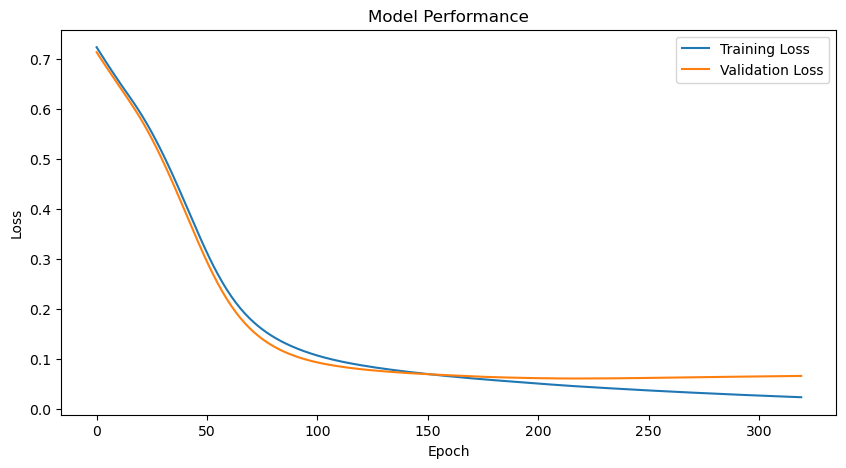

In [140]:
# plot the train and validation loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Performance')
plt.legend()
plt.show()